In [2]:
import sys
import os
import sys
curr_dir = os.path.dirname(os.getcwd())
parent_dir = os.path.abspath(os.path.join(curr_dir, os.pardir,))
print(parent_dir)
sys.path.append(parent_dir)  # Add parent directory to path for importing Net
import liset_tk.lists_sessions as lists_sessions
from process_signal import *
from plot_raster import *
from run_network import run_network
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples


In [3]:
sessions_channels=lists_sessions.channel_sessions

In [4]:
path=r"C:\Madrid_tests"
name="2025-09-24_15-13-10"
downsample=False
normalize=True
numSamples=False
channel=sessions_channels[name]-1
fs=30000

    
  

Loading data from session: 2025-09-24_15-13-10
Starting from 0 :D
Normalizing data... Done!
Shape of loaded data after downsampling and z-score:  (9909221, 40)
C:\Madrid_tests\annotations\HFO_Events\events_2025-09-24_15-13-10\events
Light stim file not found: C:\Madrid_tests\annotations\HFO_Events\events_2025-09-24_15-13-10\events\events_light.txt not found.
⚠️ TTL signal not detected or too low amplitude.
Loaded 84 ground truth ripple events.
Loaded 108 SNN predicted ripple events.
⚠️ No light stimulation events loaded.
✅ Loading complete!- session 2025-09-24_15-13-10


c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\raster\visualization.py:136: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\NCN\miniconda3\envs\lava_snn_ripples\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


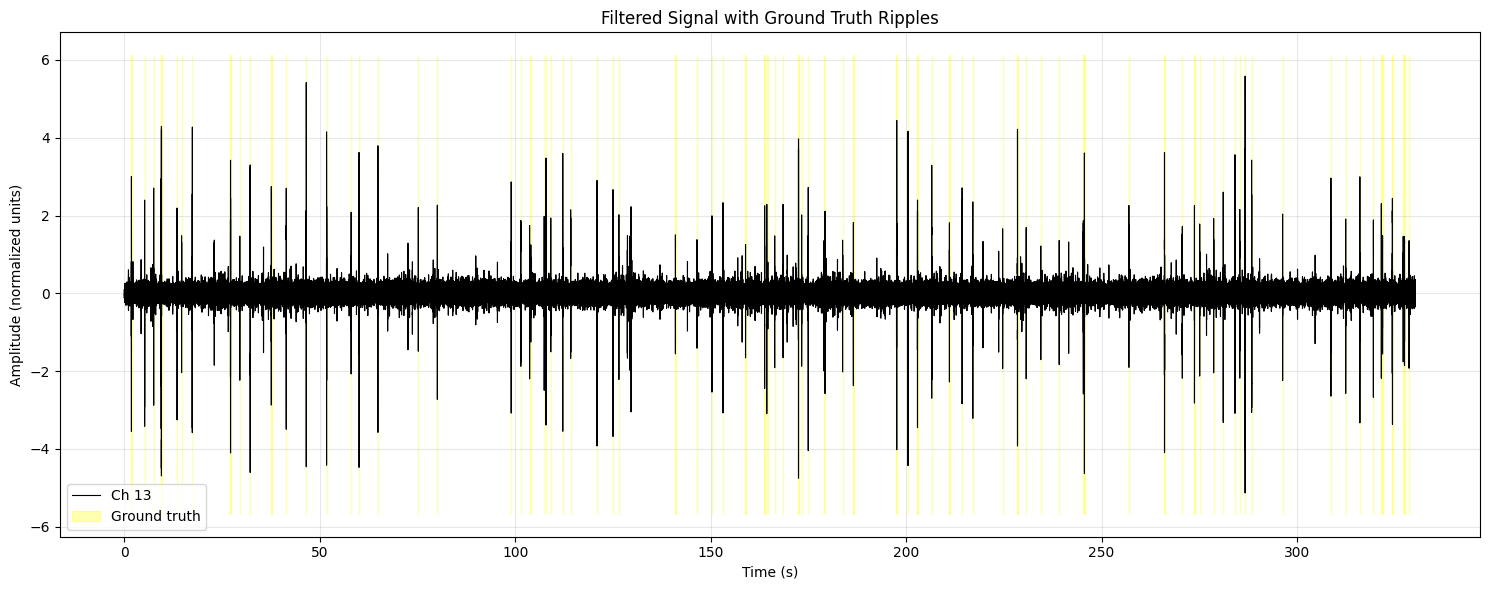

In [5]:
# Example usage
signal, ripples = load_experimental_data(
    path=path,
    name=name,
    downsample=downsample,
    normalize=normalize,
    numSamples=numSamples,
    start=0,
    verbose=True,
    original_fs=30000,
    channel=channel,
    invert=False,
    offset=0,
    load_data=True,
    visualize=True
)

In [6]:


# raw = input("Enter time window to spikify (e.g., 20.0 or 10,20,30; leave empty for none): ").strip()
# if raw == "":
#     window = None
# else:
#     # split by commas if present
#     parts = [p.strip() for p in raw.split(",")]
#     # convert to float
#     window = [float(p) for p in parts if p != ""]

ripple_seconds=ripples/30000  # convert to seconds
window=(100,150)

In [7]:
spk,thr=spikify_signal( # Something really weird here
signal,
fs=fs,
time_max=20.0,
overlap=0.5,
adapt_threshold=True,
percentile=False,
window_size=0.10,
sample_ratio=0.25,
scaling_factor=1.0,
refractory=0.0003,
factor=30,
initial_value=None,
external_window=window,
ripples=ripple_seconds,
)

print(f"window: {window}")
print(f"spk.shape: {spk.shape}")
# spk=np.zeros((100,2))

window: (100, 150)
spk.shape: (50000, 2)


In [8]:

prefix = "updnb4ds_100_7"
res = run_network(spk, prefix, export_spikes=False)


Using device: cpu
Loading model: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\raster\..\out\updnb4ds_100_7_trained_net_loss.pth


In [17]:
def plot_combined_simulation(
    signal,
    up_dn_spikes,
    lif1_spikes=None,
    lif2_spikes=None,
    lif_out_spikes=None,
    fs_signal=30000,
    fs_spikes=1000,
    ripples=None,
    window=None,
    labels=("UP_DN", "LIF1", "LIF2", "LIF_OUT"),
    colors=None,
    ripple_color="yellow",
    ripple_alpha=0.25,
    figsize=(15, 10),
):
    """
    Combines signal plot and raster plot into one figure with shared x-axis.
    
    signal:      filtered LFP already aligned to window (shape N)
    up_dn_spikes: spikified data already aligned (N_spikes, 2)
    lif1_spikes, lif2_spikes, lif_out_spikes: spike data for raster (aligned)
    fs_signal:   sampling rate of signal
    fs_spikes:   sampling rate of spikes
    ripples:     ripple timestamps in *seconds* relative to whole session
    window:      (start_s, end_s) used only to determine which ripples appear and x-axis limits
    """
    
    # Create figure
    fig, axes = plt.subplots(2, 1, sharex=True, figsize=figsize, gridspec_kw={'height_ratios': [0.6, 1.2]})
    ax_sig = axes[0]
    ax_rast = axes[1]

    w_start, w_end = window if window is not None else (0, len(signal)/fs_signal)

    # ------------------------------------------------------
    # TOP PLOT: Signal + UP/DN Spikes
    # ------------------------------------------------------
    
    # Time axes
    t_sig = np.arange(len(signal)) / fs_signal        # in seconds
    t_spk = np.arange(len(up_dn_spikes)) / fs_spikes  # in seconds

    # Convert to milliseconds
    # t_sig_ms = t_sig * 1000
    # t_spk_ms = t_spk * 1000
    t_sig_plot = t_sig
    t_spk_plot = t_spk

    # Plot LFP
    ax_sig.plot(t_sig_plot, signal, color="black", alpha=0.6, lw=0.8, label="Filtered LFP")

    # Plot UP/DN spikes
    up_times  = t_spk_plot[up_dn_spikes[:,0] > 0]
    dn_times  = t_spk_plot[up_dn_spikes[:,1] > 0]

    ymax = np.max(signal)
    ymin = np.min(signal)

    ax_sig.vlines(up_times, ymax*0.75, ymax*1, color="red", lw=0.7, label="UP")
    ax_sig.vlines(dn_times, ymin, ymin*0.75, color="blue", lw=0.7, label="DOWN")

    # Plot ripples on Top
    if ripples is not None:
        for idx, r in enumerate(ripples):
            if isinstance(r, (int, float)):
                r_start = r
                r_end   = r
            else:
                r_start, r_end = r

            if r_end < w_start or r_start > w_end:
                continue

            rs_plot = (r_start - w_start)
            re_plot = (r_end   - w_start)

            ax_sig.axvspan(
                rs_plot, re_plot,
                color=ripple_color,
                alpha=ripple_alpha,
                label="Ripple" if idx == 0 else None
            )

    ax_sig.set_ylabel("Amplitude (a.u.)",fontsize=14)
    # ax_sig.set_title("Filtered LFP + UP/DN Spikes")
    # ax_sig.legend(loc="upper right")
    ax_sig.spines[['left','bottom','top','right']].set_linewidth(1.3)
    ax_sig.spines[['right','bottom','top']].set_visible(False)
    ax_sig.set_yticks([-3,0,3])
    ax_sig.tick_params(axis='y', labelsize=13,width=1.3)
    ax_sig.tick_params(axis='x',width=0)



    # ------------------------------------------------------
    # BOTTOM PLOT: Raster
    # ------------------------------------------------------
    
    if colors is None:
        colors = {
            "UP_DN": ["red", "blue"],
            "LIF1": "black",
            "LIF2": "gray",
            "LIF_OUT": "purple",
        }

    groups = [up_dn_spikes, lif1_spikes, lif2_spikes, lif_out_spikes]
    y_offset = 0

    for g_idx, group in enumerate(groups):
        if group is None:
            continue
        original_y=y_offset
        label = labels[g_idx] if g_idx < len(labels) else f"Group {g_idx}"
        color_setting = colors.get(label, "black")

        per_neuron_lists = None
        if isinstance(group, np.ndarray):
            if group.ndim == 2:
                T, N = group.shape
                per_neuron_lists = [np.where(group[:, n] > 0)[0] for n in range(N)]
            else:
                per_neuron_lists = [group]
        elif isinstance(group, (list, tuple)):
            per_neuron_lists = [np.asarray(s) for s in group]
        else:
            try:
                per_neuron_lists = [np.asarray(s) for s in group]
            except Exception:
                continue

        for neuron_idx, spikes in enumerate(per_neuron_lists):
            times = np.asarray(spikes) / fs_spikes # Convert to seconds
            if times.size == 0:
                continue

            if isinstance(color_setting, list):
                color = color_setting[neuron_idx % len(color_setting)]
            else:
                color = color_setting

            y_val = y_offset + neuron_idx

            # ax_rast.scatter(
            #     times,
            #     np.full_like(times, y_val),
            #     s=3,
            #     color=color,
            #     label=label if neuron_idx == 0 else None
            # )
            ax_rast.vlines(
                times,
                y_val - 0.4,
                y_val + 0.4,
                color=color,
                lw=0.7,
                label=label if neuron_idx == 0 else None
            )
        y_offset += len(per_neuron_lists) + 2
        ax_rast.axhspan(original_y-1.0, y_offset-2., color="white" if g_idx%2 == 0 else "lightgray", alpha=0.3)


    # Plot ripples on Bottom
    if ripples is not None:
        for idx, r in enumerate(ripples):
            if isinstance(r, (int, float)):
                r_start = r
                r_end = r
            else:
                r_start, r_end = r

            if r_start <= w_end and r_end >= w_start:
                rs = (r_start - w_start)
                re = (r_end   - w_start)

                ax_rast.axvspan(
                    rs, re,
                    ymin=0, ymax=1,
                    color=ripple_color,
                    alpha=ripple_alpha,
                    zorder=0
                )

    ax_rast.set_xlabel("Time [s]",fontsize=14)
    ax_rast.tick_params(axis='x', labelsize=13)
    ax_rast.set_xticks(np.arange(10,int(w_end - w_start)+1,10))
    # ax_rast.set_ylabel("Neuron index")
    ax_rast.spines[['left','bottom','top','right']].set_linewidth(1.3)
    ax_rast.spines[['top','right']].set_visible(False)
    # ax_rast.spines[]
    ax_rast.set_yticks([])
    if window is not None:
        ax_rast.set_xlim(0, (window[1] - window[0]))
    ax_rast.set_title("Raster + Ripples")
    
    # Handle legend for raster (avoid duplicates)
    # handles, labels_legend = ax_rast.get_legend_handles_labels()
    # by_label = dict(zip(labels_legend, handles))
    # ax_rast.legend(by_label.values(), by_label.keys(), loc="upper right")

    plt.tight_layout()
    plt.show()
    return fig, axes

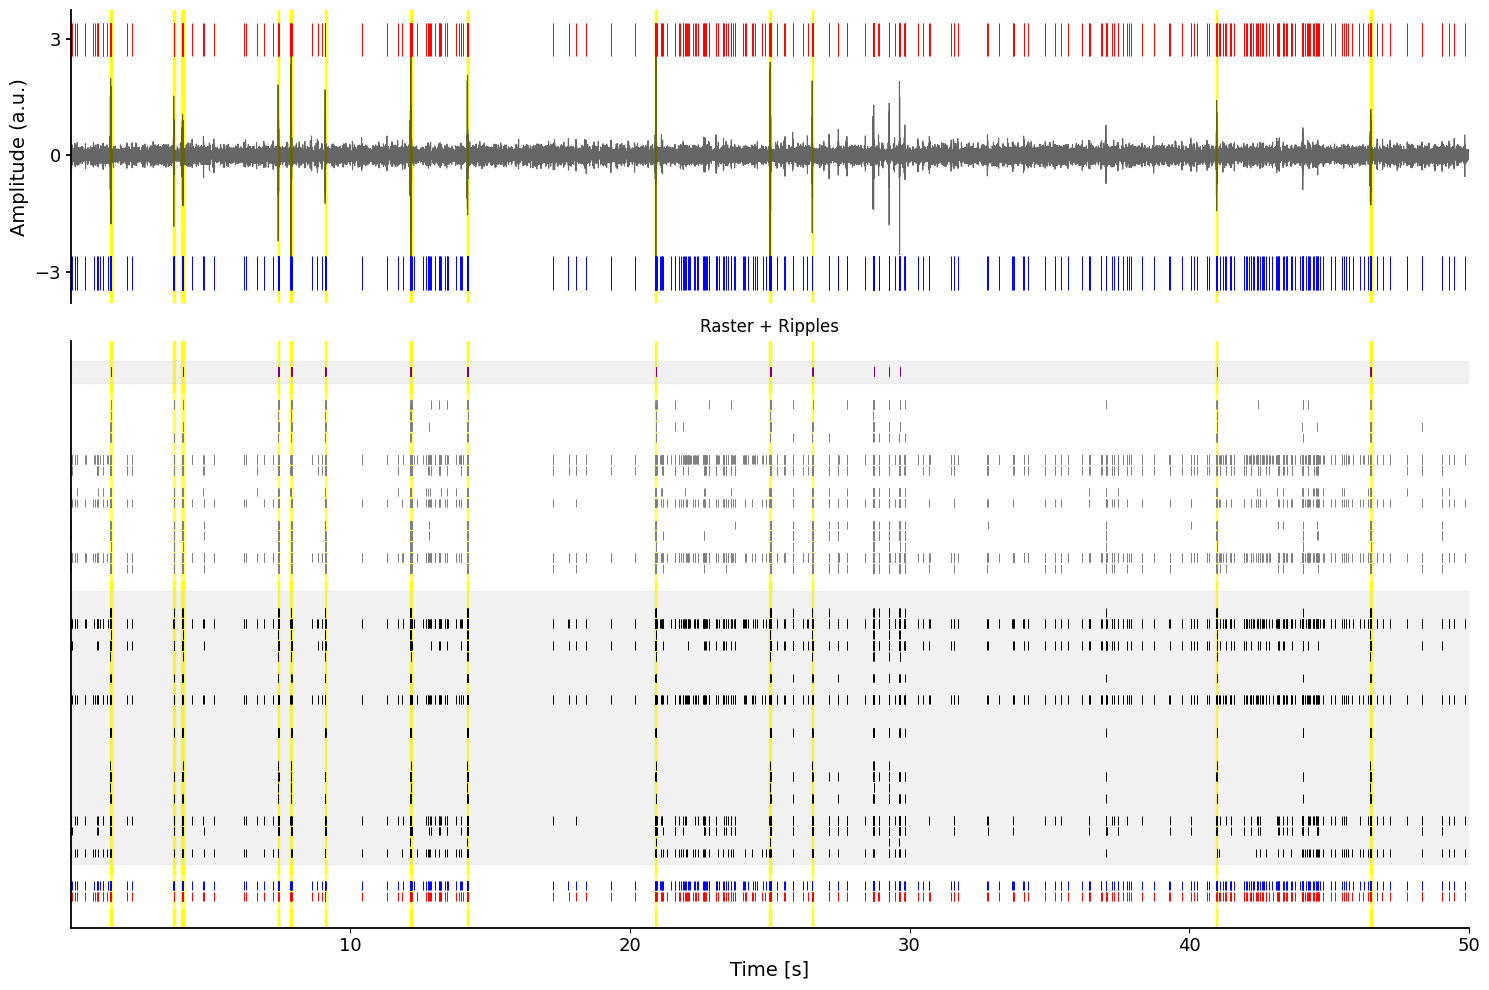

In [18]:
# Example usage of the combined function
fig,axes=plot_combined_simulation(
    signal=signal[ (int(window[0]*fs) if window is not None else 0):(int(window[1]*fs) if window is not None else len(signal)) ] if window is not None else signal,
    up_dn_spikes=spk,
    lif1_spikes=res['lif1'],
    lif2_spikes=res['lif2'],
    lif_out_spikes=res['out'],
    fs_signal=fs,
    fs_spikes=1000,
    ripples=ripple_seconds,
    ripple_alpha=0.9,
    window=window,
    labels=("UP_DN", "LIF1", "LIF2", "LIF_OUT"),
    figsize=(15, 10)
)
# fig.savefig(f"combined_simulation_{name}.svg")
# fig.savefig(f"combined_simulation_{name}.png", dpi=300)

In [ ]:
def plot_combined_simulation(
    signal,
    up_dn_spikes,
    lif1_spikes=None,
    lif2_spikes=None,
    lif_out_spikes=None,
    fs_signal=30000,
    fs_spikes=1000,
    ripples=None,
    window=None,
    labels=("UP_DN", "LIF1", "LIF2", "LIF_OUT"),
    colors=None,
    ripple_color="gold",
    ripple_alpha=0.25,
    figsize=(15, 10),
):
    """
    Combines signal plot and raster plot into one figure with shared x-axis.
    
    signal:      filtered LFP already aligned to window (shape N)
    up_dn_spikes: spikified data already aligned (N_spikes, 2)
    lif1_spikes, lif2_spikes, lif_out_spikes: spike data for raster (aligned)
    fs_signal:   sampling rate of signal
    fs_spikes:   sampling rate of spikes
    ripples:     ripple timestamps in *seconds* relative to whole session
    window:      (start_s, end_s) used only to determine which ripples appear and x-axis limits
    """
    
    # Create figure
    fig, axes = plt.subplots(2, 1, sharex=True, figsize=figsize, gridspec_kw={'height_ratios': [0.6, 1.2]})
    ax_sig = axes[0]
    ax_rast = axes[1]

    w_start, w_end = window if window is not None else (0, len(signal)/fs_signal)

    # ------------------------------------------------------
    # TOP PLOT: Signal + UP/DN Spikes
    # ------------------------------------------------------
    
    # Time axes
    t_sig = np.arange(len(signal)) / fs_signal        # in seconds
    t_spk = np.arange(len(up_dn_spikes)) / fs_spikes  # in seconds

    # Convert to milliseconds
    # t_sig_ms = t_sig * 1000
    # t_spk_ms = t_spk * 1000
    t_sig_plot = t_sig
    t_spk_plot = t_spk

    # Plot LFP
    ax_sig.plot(t_sig_plot, signal, color="black",alpha=0.6, lw=0.8, label="Filtered LFP")

    # Plot UP/DN spikes
    up_times  = t_spk_plot[up_dn_spikes[:,0] > 0]
    dn_times  = t_spk_plot[up_dn_spikes[:,1] > 0]

    ymax = np.max(signal)
    ymin = np.min(signal)

    ax_sig.vlines(up_times, ymax*0.75, ymax*1, color="red", lw=0.7, label="UP")
    ax_sig.vlines(dn_times, ymin, ymin*0.75, color="blue", lw=0.7, label="DOWN")

    # Plot ripples on Top
    if ripples is not None:
        for idx, r in enumerate(ripples):
            if isinstance(r, (int, float)):
                r_start = r
                r_end   = r
            else:
                r_start, r_end = r

            if r_end < w_start or r_start > w_end:
                continue

            rs_plot = (r_start - w_start)
            re_plot = (r_end   - w_start)

            ax_sig.axvspan(
                rs_plot, re_plot,
                color=ripple_color,
                alpha=ripple_alpha,
                label="Ripple" if idx == 0 else None
            )

    ax_sig.set_ylabel("Amplitude (a.u.)",fontsize=14)
    # ax_sig.set_title("Filtered LFP + UP/DN Spikes")
    # ax_sig.legend(loc="upper right")
    ax_sig.spines[['left','bottom','top','right']].set_linewidth(1.3)
    ax_sig.spines[['right','bottom','top']].set_visible(False)
    ax_sig.set_yticks([-3,0,3])
    ax_sig.tick_params(axis='y', labelsize=13,width=1.3)
    ax_sig.tick_params(axis='x',width=0)



    # ------------------------------------------------------
    # BOTTOM PLOT: Raster
    # ------------------------------------------------------
    
    if colors is None:
        colors = {
            "UP_DN": ["red", "blue"],
            "LIF1": "steelblue",
            "LIF2": "gray",
            "LIF_OUT": "purple",
        }

    groups = [
            # up_dn_spikes, 
            lif1_spikes, 
            lif2_spikes, 
            lif_out_spikes]
    
    # Reverse order so UP_DN is on top
    groups = groups[::-1]
    if labels is not None:
        labels = list(labels)[::-1]

    y_offset = 0
    y_ticks=[]
    for g_idx, group in enumerate(groups):
        y_lines=[]
        if group is None:
            continue
        original_y=y_offset
        label = labels[g_idx] if g_idx < len(labels) else f"Group {g_idx}"
        color_setting = colors.get(label, "black")
        
        # Determine scale factor for this group
        # Groups 0 (bottom, LIF_OUT) and 3 (top, UP_DN) get larger scaling
        scale_factor = 2.5 if label in ["UP_DN","LIF_OUT"] else 1.0
        
        per_neuron_lists = None
        if isinstance(group, np.ndarray):
            if group.ndim == 2:
                T, N = group.shape
                per_neuron_lists = [np.where(group[:, n] > 0)[0] for n in range(N)]
            else:
                per_neuron_lists = [group]
        elif isinstance(group, (list, tuple)):
            per_neuron_lists = [np.asarray(s) for s in group]
        else:
            try:
                per_neuron_lists = [np.asarray(s) for s in group]
            except Exception:
                continue

        N_neurons = len(per_neuron_lists)
        y_ticks.append(y_offset + ((N_neurons-1)*scale_factor)/2)
        for neuron_idx, spikes in enumerate(per_neuron_lists):
            times = np.asarray(spikes) / fs_spikes # Convert to seconds
            if times.size == 0:
                continue

            if isinstance(color_setting, list):
                color = color_setting[neuron_idx % len(color_setting)]
            else:
                color = color_setting

            # Calculate y position with scaling
            # Reverse order within group: first index (0) on top
            y_val = y_offset + (N_neurons - 1 - neuron_idx) * scale_factor

            # Height of the tick
            half_height = 0.4 * scale_factor
            if neuron_idx==0:
                y_lines.append(y_val+half_height+1.0)

            ax_rast.vlines(
                times,
                y_val - half_height,
                y_val + half_height,
                color=color,
                lw=0.7,
                label=label if neuron_idx == 0 else None
            )

        # Update offset for next group
        y_offset += (len(per_neuron_lists) * scale_factor) + 2
        y_lines.append(y_val-half_height-1.0)
        # Background span
        # ax_rast.axhspan(original_y - scale_factor, y_offset - 2.0 + scale_factor*0.5, color="white" if g_idx%2 == 0 else "lightgray", alpha=0.3)
        # ax_rast.axhspan(original_y - scale_factor*0.5, original_y + (N_neurons - 0.5)*scale_factor, color=color, alpha=0.01, zorder=-1)
        ax_rast.axhspan(min(y_lines), max(y_lines), facecolor=color, alpha=0.001, zorder=-1)
        ax_rast.axhspan(min(y_lines), max(y_lines), facecolor="none", alpha=0.4,edgecolor=color, zorder=-1)

    # Plot ripples on Bottom
    if ripples is not None:
        for idx, r in enumerate(ripples):
            if isinstance(r, (int, float)):
                r_start = r
                r_end = r
            else:
                r_start, r_end = r

            if r_start <= w_end and r_end >= w_start:
                rs = (r_start - w_start)
                re = (r_end   - w_start)

                ax_rast.axvspan(
                    rs, re,
                    ymin=0, ymax=1,
                    color=ripple_color,
                    alpha=ripple_alpha,
                    zorder=0
                )

    ax_rast.set_xlabel("Time [s]",fontsize=14)
    ax_rast.tick_params(axis='x', labelsize=13)
    ax_rast.set_xticks(np.arange(10,int(w_end - w_start)+1,10))
    # ax_rast.set_ylabel("Neuron index")
    ax_rast.spines[['left','bottom','top','right']].set_linewidth(2)
    ax_rast.spines[['right','top']].set_visible(False)
    # ax_rast.spines[]
    
    ax_rast.set_yticks(y_ticks)
    ax_rast.set_yticklabels([])

    labels = [
        "LIF_OUT\n(n=1)",
        "LIF2\n(n=16)",
        "LIF1\n(n=24)",
    ]

    for y, lab in zip(y_ticks, labels):
        ax_rast.text(
            -0.02, y, lab,
            transform=ax_rast.get_yaxis_transform(),
            rotation=90,
            ha="center",
            va="center",
            fontsize=13
        )
    
    ax_rast.tick_params(axis='y',direction='out',pad=15,width=1.3)
    if window is not None:
        ax_rast.set_xlim(0, (window[1] - window[0]))
    # ax_rast.set_title("Raster + Ripples")
    
    # Handle legend for raster (avoid duplicates)
    # handles, labels_legend = ax_rast.get_legend_handles_labels()
    # by_label = dict(zip(labels_legend, handles))
    # ax_rast.legend(by_label.values(), by_label.keys(), loc="upper right")

    plt.tight_layout()
    plt.show()
    return fig, axes

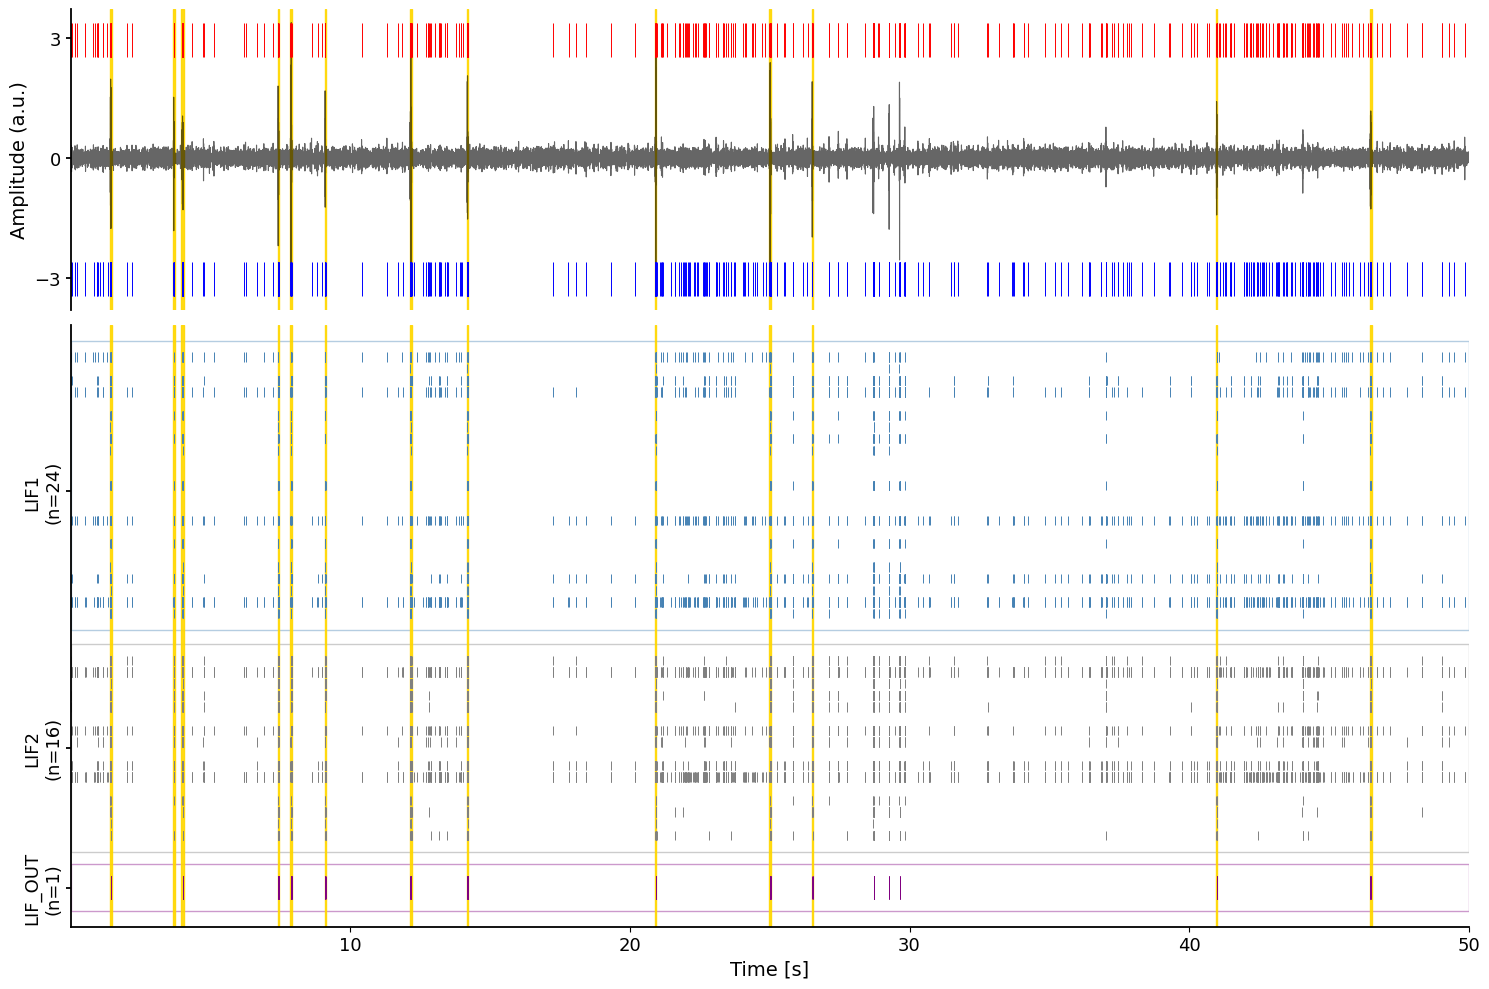

In [20]:
# Example usage of the combined function
fig,axes=plot_combined_simulation(
    signal=signal[ (int(window[0]*fs) if window is not None else 0):(int(window[1]*fs) if window is not None else len(signal)) ] if window is not None else signal,
    up_dn_spikes=spk,
    lif1_spikes=res['lif1'],
    lif2_spikes=res['lif2'],
    lif_out_spikes=res['out'],
    fs_signal=fs,
    fs_spikes=1000,
    ripples=ripple_seconds,
    ripple_color="gold",
    ripple_alpha=0.9,
    window=window,
    figsize=(15, 10)
)
fig.savefig(f"combined_simulation_{name}.svg", dpi=300)
fig.savefig(f"combined_simulation_{name}.png", dpi=300)

In [21]:
def plot_axis_and_legend(
    signal,
    up_dn_spikes,
    lif1_spikes=None,
    lif2_spikes=None,
    lif_out_spikes=None,
    fs_signal=30000,
    fs_spikes=1000,
    ripples=None,
    window=None,
    labels=("UP_DN", "LIF1", "LIF2", "LIF_OUT"),
    colors=None,
    ripple_color="yellow",
    ripple_alpha=0.25,
    figsize=(15, 10),
):
    """
    Generates a plot with only axes and legends (no data) for SVG export.
    """
    import matplotlib.lines as mlines
    import matplotlib.patches as mpatches

    # Create figure
    fig, axes = plt.subplots(2, 1, sharex=True, figsize=figsize, gridspec_kw={'height_ratios': [0.6, 1.2]})
    ax_sig = axes[0]
    ax_rast = axes[1]

    w_start, w_end = window if window is not None else (0, len(signal)/fs_signal)

    # ------------------------------------------------------
    # TOP PLOT: Axis & Legend
    # ------------------------------------------------------
    
    # Axis Styling
    ax_sig.set_ylabel("Amplitude (a.u.)",fontsize=14)
    ax_sig.spines[['left','bottom','top','right']].set_linewidth(1.3)
    ax_sig.spines[['right','bottom','top']].set_visible(False)
    ax_sig.set_yticks([-3,0,3])
    ax_sig.tick_params(axis='y', labelsize=13,width=1.3)
    ax_sig.tick_params(axis='x',width=0)

    # Legend
    h_lfp = mlines.Line2D([], [], color="black", alpha=0.6, lw=1.3, label="Filtered LFP")
    h_up = mlines.Line2D([], [], color="red", lw=1.3, label="UP")
    h_dn = mlines.Line2D([], [], color="blue", lw=1.3, label="DOWN")
    h_rip = mpatches.Patch(color=ripple_color, alpha=ripple_alpha, label="Ripple")
    
    ax_sig.legend(handles=[h_lfp, h_up, h_dn, h_rip], loc="upper right",fontsize=13)

    # ------------------------------------------------------
    # BOTTOM PLOT: Axis & Legend
    # ------------------------------------------------------
    
    if colors is None:
        colors = {
            "UP_DN": ["red", "blue"],
            "LIF1": "steelblue",
            "LIF2": "gray",
            "LIF_OUT": "purple",
        }

    groups = [
            # up_dn_spikes, 
            lif1_spikes, 
            lif2_spikes, 
            lif_out_spikes]
    
    # Reverse order so UP_DN is on top
    groups = groups[::-1]
    if labels is not None:
        labels = list(labels)[::-1]

    y_offset = 0
    y_ticks=[]
    
    # Calculate layout (same logic as plot_combined_simulation)
    for g_idx, group in enumerate(groups):
        if group is None:
            continue
        
        label = labels[g_idx] if g_idx < len(labels) else f"Group {g_idx}"
        
        # Determine scale factor for this group
        scale_factor = 2.5 if label in ["UP_DN","LIF_OUT"] else 1.0
        
        per_neuron_lists = None
        if isinstance(group, np.ndarray):
            if group.ndim == 2:
                T, N = group.shape
                per_neuron_lists = [np.where(group[:, n] > 0)[0] for n in range(N)]
            else:
                per_neuron_lists = [group]
        elif isinstance(group, (list, tuple)):
            per_neuron_lists = [np.asarray(s) for s in group]
        else:
            try:
                per_neuron_lists = [np.asarray(s) for s in group]
            except Exception:
                continue

        N_neurons = len(per_neuron_lists)
        y_ticks.append(y_offset + ((N_neurons-1)*scale_factor)/2)
        
        # Update offset for next group
        y_offset += (len(per_neuron_lists) * scale_factor) + 2

    # Axis Styling
    ax_rast.set_xlabel("Time [s]",fontsize=14)
    ax_rast.tick_params(axis='x', labelsize=13)
    ax_rast.set_xticks(np.arange(10,int(w_end - w_start)+1,10))
    ax_rast.spines[['left','bottom','top','right']].set_linewidth(1.3)
    ax_rast.spines[['right','top']].set_visible(False)

    # Set Y limits to match the calculated offset
    ax_rast.set_ylim(-4, y_offset)

    ax_rast.set_yticks(y_ticks)
    ax_rast.set_yticklabels([])

    # Hardcoded labels to match plot_combined_simulation
    # Note: These should ideally be dynamic based on N_neurons, but matching user's code
    labels_text = [
        "LIF_OUT\n(n=1)",
        "LIF2\n(n=16)",
        "LIF1\n(n=24)",
    ]

    for y, lab in zip(y_ticks, labels_text):
        ax_rast.text(
            -0.02, y, lab,
            transform=ax_rast.get_yaxis_transform(),
            rotation=90,
            ha="center",
            va="center",
            fontsize=13
        )
    
    ax_rast.tick_params(axis='y',direction='out',pad=15,width=1.3)
    
    if window is not None:
        ax_rast.set_xlim(0, (window[1] - window[0]))
    else:
        ax_rast.set_xlim(0, len(signal)/fs_signal)
        
    # ax_rast.set_title("Raster + Ripples")

    # Legend
    legend_handles = []
    
    # Add handles for LIF groups
    # Note: labels list is reversed, so we iterate it
    for label in labels:
        if label == "UP_DN":
            continue # Already in top legend
        
        color_setting = colors.get(label, "black")
        if isinstance(color_setting, list):
             c = color_setting[0]
        else:
             c = color_setting
             
        h = mlines.Line2D([], [], color=c, lw=1.3, label=label,)
        legend_handles.append(h)
            
    # Add Ripple
    legend_handles.append(mpatches.Patch(color=ripple_color, alpha=ripple_alpha, label="Ripple"))
    
    ax_rast.legend(handles=legend_handles, loc="upper right",fontsize=13)

    plt.tight_layout()
    return fig, axes

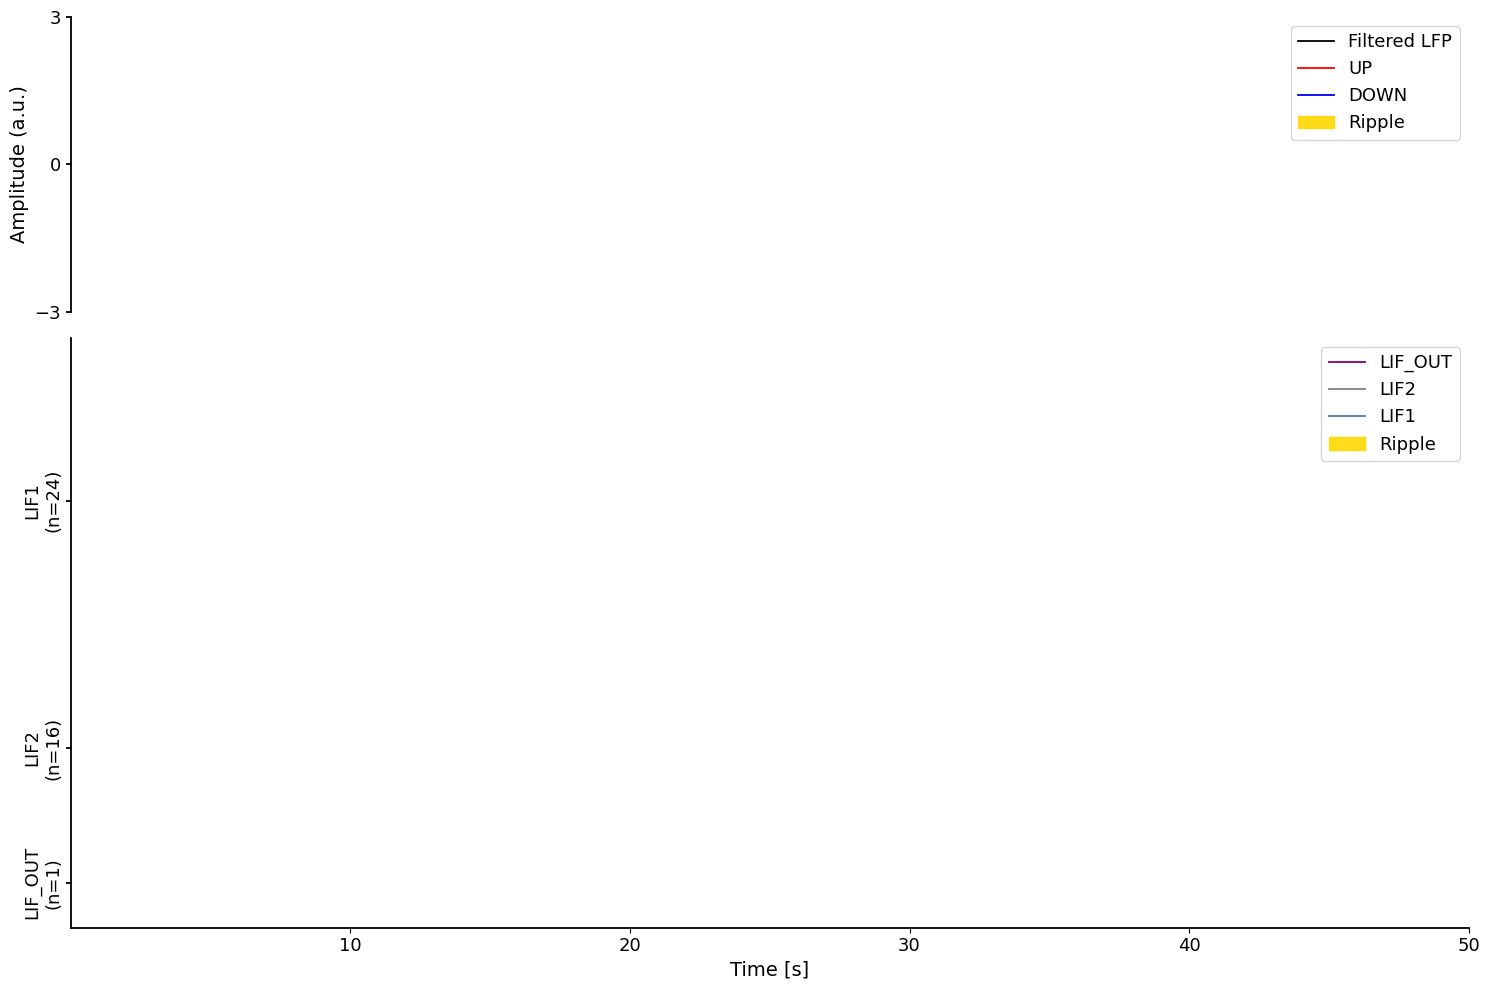

In [15]:
# Generate and save the axis/legend only plot as SVG
fig_svg, axes_svg = plot_axis_and_legend(
    signal=signal[ (int(window[0]*fs) if window is not None else 0):(int(window[1]*fs) if window is not None else len(signal)) ] if window is not None else signal,
    up_dn_spikes=spk,
    lif1_spikes=res['lif1'],
    lif2_spikes=res['lif2'],
    lif_out_spikes=res['out'],
    fs_signal=fs,
    fs_spikes=1000,
    ripples=ripple_seconds,
    ripple_alpha=0.9,
    ripple_color="gold",
    window=window,
    labels=("UP_DN", "LIF1", "LIF2", "LIF_OUT"),
    figsize=(15, 10)
)
fig_svg.savefig(f"axis_legend_{name}.svg", format="svg")